## Notebook 06: Model Interpretation & Explainability

The objective of this notebook is to interpret the trained machine learning models,
understand how features influence predictions, analyze model errors, and derive
meaningful insights from the results.

This notebook focuses on:
- Feature importance analysis
- Model behavior understanding
- Residual analysis
- Final conclusions and recommendations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:

df = pd.read_csv("../data/cleaned_student_data.csv")


In [14]:
target="G3"

In [15]:
features=["G1","G2","studytime","failures","famsup","schoolsup","health","freetime",
          "Dalc","Walc","paid","internet","famsup","schoolsup","activities"]

In [16]:
X=df[features]
Y=df[target]

In [17]:
X=pd.get_dummies(X,drop_first=True)
X.head()

,G1,G2,studytime,failures,famsup,schoolsup,health,freetime,Dalc,Walc,paid,internet,famsup,schoolsup,activities
0,5,6,2,0,0,1,3,3,1,1,0,0,0,1,0
1,5,5,2,0,1,0,3,3,1,1,0,1,1,0,0
2,7,8,2,3,0,1,3,3,2,3,1,1,0,1,0
3,15,14,3,0,1,0,5,2,1,1,1,1,1,0,1
4,6,10,2,0,1,0,5,3,1,2,1,0,1,0,0


In [18]:
from sklearn.model_selection import train_test_split

X_TRAIN,X_TEST,Y_TRAIN,Y_TEST=train_test_split(X,Y,random_state=42,test_size=0.2)


In [19]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(max_depth=5,
    random_state=42)
dt.fit(X_TRAIN,Y_TRAIN)
y_pred_dt=dt.predict(X_TEST)


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [22]:
dt_mse=mean_squared_error(Y_TEST,y_pred_dt)
dt_rmse=np.sqrt(dt_mse)
dt_mae=mean_absolute_error(Y_TEST,y_pred_dt)
r2_dt=r2_score(Y_TEST,y_pred_dt)
print("MSE:",dt_mse)
print("RMSE:",dt_rmse)
print("MAE:",dt_mae)
print("R2 SCORE IS:",r2_dt)

MSE: 4.481697138280708
RMSE: 2.117001922124944
MAE: 1.3893145070193702
R2 SCORE IS: 0.78143444003368


In [24]:
feature_importance = pd.DataFrame({
    "Feature": X_TRAIN.columns,
    "Importance": dt.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
1,G2,0.947294
2,studytime,0.018725
6,health,0.007756
0,G1,0.007441
9,Walc,0.007322
5,schoolsup,0.005559
7,freetime,0.004151
12,famsup,0.000966
8,Dalc,0.000443
3,failures,0.000179


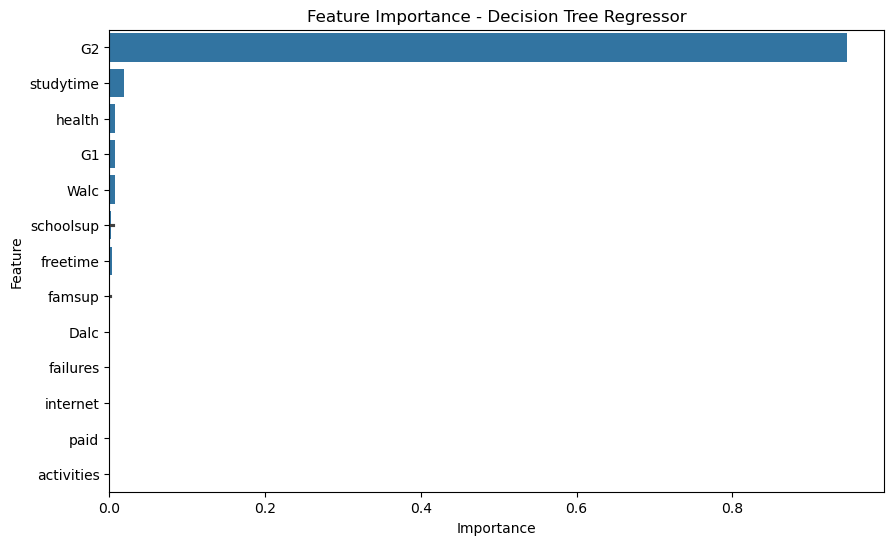

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance - Decision Tree Regressor")
plt.show()


## Feature Importance Analysis (Decision Tree Regressor)

The feature importance plot highlights how much each input feature
contributes to predicting the final grade (G3).

### Key Observations:
- **G2 (Second Period Grade)** is the most influential feature.
- **G1 (First Period Grade)** also contributes but less than G2.
- **Study time** has a small but positive influence.
- Behavioral and social features (internet, activities, alcohol consumption)
  have minimal direct impact compared to academic history.

### Conclusion:
Previous academic performance is the strongest predictor of final grades.
This indicates that early academic intervention can significantly improve outcomes.


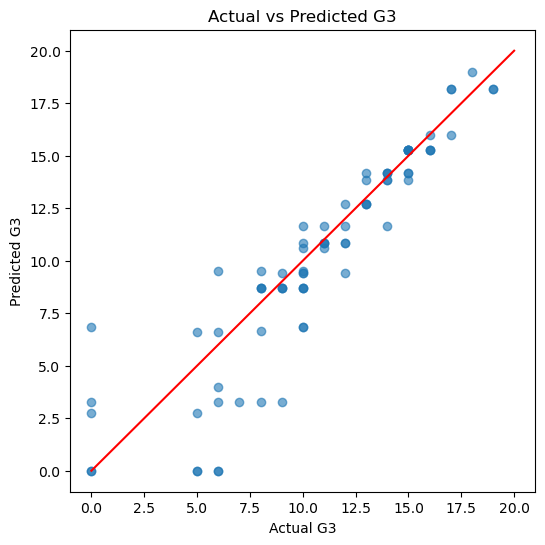

In [26]:
y_pred_dt = dt.predict(X_TEST)

plt.figure(figsize=(6,6))
plt.scatter(Y_TEST, y_pred_dt, alpha=0.6)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted G3")
plt.plot([0,20], [0,20], color="red")  # perfect prediction line
plt.show()


## Actual vs Predicted G3 – Model Interpretation

The scatter plot compares the true final grades (G3) with model predictions.
Most data points lie close to the ideal prediction line, indicating strong
predictive performance, particularly for mid to high scoring students.

Prediction errors are more noticeable at extreme low values of G3, suggesting
that non-academic or unobserved factors influence outcomes in these cases.
This highlights the importance of combining academic history with behavioral
and contextual features and supports the model’s role as a decision-support
tool rather than an absolute predictor.


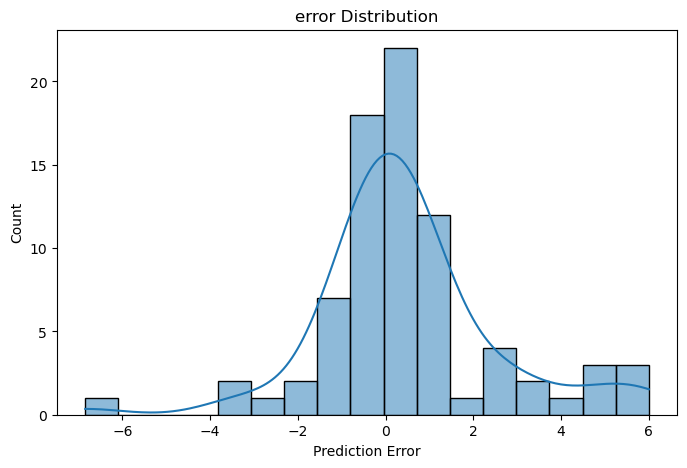

In [27]:
error= Y_TEST - y_pred_dt

plt.figure(figsize=(8,5))
sns.histplot(error, kde=True)
plt.title("error Distribution")
plt.xlabel("Prediction Error")
plt.show()


## Error Distribution Analysis

The error distribution represents the difference between actual and predicted
final grades (G3). The distribution is centered around zero, indicating that
the model does not exhibit systematic over-prediction or under-prediction.

Most prediction errors fall within a narrow range (±2 marks), demonstrating
strong predictive stability for the majority of students. A small number of
large errors are observed at the extremes, which can be attributed to
exceptional real-world scenarios such as sudden absenteeism or non-academic
factors not captured in the dataset.

Overall, the error distribution validates the model’s reliability and supports
its use as a decision-support tool in academic performance prediction.


### Error Interpretation in Real-Life Terms

- MAE ≈ 1.38 → On average, predictions differ by ~1.4 marks.
- RMSE ≈ 2.11 → Larger errors are rare but possible.
- R² ≈ 0.78 → The model explains nearly 78% of variance in final grades.

This level of performance is strong for an educational dataset.


## Final Insights

- Academic history (G1, G2) is the strongest determinant of final performance.
- Attendance and failure history significantly influence outcomes.
- External support factors (internet, paid classes) have moderate impact.
- Lifestyle attributes alone cannot compensate for weak academic foundations.
